# Imports

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Data

## Generator

In [2]:

pGa_CONST = {
    'gpt-4o': 0.93478,
    'gpt-4-turbo': 0.872,
    'claude_3_opus': 0.95402,
    'gemini-1.5-pro': 0.92846,
    'deepseek-chat': 0.92841,
    'qwen-coder-plus': 0.93117
}

df_pg = pd.DataFrame(pGa_CONST.items(), columns=['generator', 'precision'])
df_pg['precision'] = df_pg['precision'] * 100
df_pg['validator'] = 'human'
df = df_pg.copy()

df

,generator,precision,validator
0,gpt-4o,93.478,human
1,gpt-4-turbo,87.200,human
2,claude_3_opus,95.402,human
3,gemini-1.5-pro,92.846,human
4,deepseek-chat,92.841,human
5,qwen-coder-plus,93.117,human


## Validator

In [3]:
MODEL_QWEN = 'qwen-coder-plus'
MODEL_DEEPSEEK = 'deepseek-chat'

MODELS = ['gpt-4-turbo', 'gpt-4o-mini', 'gpt-4o', 'claude_3_opus', 'claude_3.5_sonnet', 'gemini-1.5-flash', 'gemini-1.5-pro', MODEL_QWEN, MODEL_DEEPSEEK, 
          'claude_3.5_haiku', 'gemini-2.5-flash-preview-04-17', 'gemini-2.5-pro-preview-03-25', 'gpt-4.1-2025-04-14', 'gpt-4.1-mini-2025-04-14']

MODELS_SHORT = {
    'gpt-4-turbo': 'GPT 4T',
    'gpt-4o-mini': 'GPT 4o-M',
    'gpt-4o': 'GPT 4o',
    'claude_3_opus': 'Opus 3',
    'claude_3.5_sonnet': 'Sonnet 3.5',
    'gemini-1.5-flash': 'G 1.5 flash',
    'gemini-1.5-pro': 'G 1.5 pro',
    MODEL_QWEN: 'Qwen-2.5 Coder',
    MODEL_DEEPSEEK: 'DeepSeek V2.5',
    'claude_3.5_haiku': 'Haiku 3.5',
    'gemini-2.5-flash-preview-04-17': 'G 2.5 flash',
    'gemini-2.5-pro-preview-03-25': 'G 2.5 pro',
    'gpt-4.1-2025-04-14': 'GPT 4.1',
    'gpt-4.1-mini-2025-04-14': 'GPT 4.1-M'
}

PVVA_CONST = np.array([0.9653183333, 0.9608816667, 0.9658983333, 0.9624083333, 0.9647516667, 0.97678, 0.9614933333, 0.9482433333, 0.97925, 0.9710183333, 0.9132133333, 0.8352533333, 0.969505, 0.9815566667])
PVIVA_CONST = np.array([0.191985, 0.2311483333, 0.2043866667, 0.17761, 0.197885, 0.0801383333, 0.1754266667, 0.23588, 0.1497233333, 0.13804, 0.3931616667, 0.519875, 0.20152, 0.1680416667])

pValid = {}
pInvalid = {}

for model, pV in zip(MODELS, PVVA_CONST):
    pValid[model] = pV

for model, pV in zip(MODELS, PVIVA_CONST):
    pInvalid[model] = pV

df_tpr = pd.DataFrame(pValid.items(), columns=['validator', 'tpr'])
df_tnr = pd.DataFrame(pInvalid.items(), columns=['validator', 'tnr'])

df_tpr['tpr'] = df_tpr['tpr'] * 100
df_tnr['tnr'] = df_tnr['tnr'] * 100


## GV

In [4]:
GV_CONST = np.array([
    [0.9185059422749999, 0.928825622776, 0.9004594180700001, 0.9065300896290001, 0.919786096257, 0.9622356495469999, 0.910621761658, 0.883652430044, 0.950240770465, 0.938395415473, 0.85125, 0.77908496732, 0.932142857143, 0.944587628866],
    [0.94554973822, 0.946225439504, 0.941297631308, 0.921106557377, 0.945585215606, 0.9708737864079999, 0.9423076923079999, 0.92458677686, 0.962051282051, 0.953271028037, 0.856697819315, 0.776135163675, 0.957991803279, 0.9761646803899999],
    [0.976506639428, 0.968270214944, 0.973604060914, 0.955440414508, 0.963730569948, 0.978439425051, 0.97, 0.961038961039, 0.9831683168319999, 0.964546402503, 0.915637860082, 0.8606557377049999, 0.9797365754809999, 0.989648033126],
    [0.959722222222, 0.9523160762940001, 0.969021065675, 0.9795918367349999, 0.965043695381, 0.97889182058, 0.956316410862, 0.94124559342, 0.9739027283510001, 0.979418886199, 0.91469816273, 0.83537414966, 0.950819672131, 0.977777777778],
    [0.972012917115, 0.962637362637, 0.9681697612729999, 0.9581105169340001, 0.982325581395, 0.979207920792, 0.9640287769779999, 0.9600355239789999, 0.979353680431, 0.971971066908, 0.936274509804, 0.8674948240170001, 0.982363315697, 0.987642585551],
    [0.9315403422980001, 0.9515738498790001, 0.951557093426, 0.970731707317, 0.957868649318, 0.986022871665, 0.972939729397, 0.933852140078, 0.9716494845360001, 0.960099750623, 0.818181818182, 0.731958762887, 0.9611307420490001, 0.979115479115],
    [0.9555061179090001, 0.945161290323, 0.954413191077, 0.966893039049, 0.966358284272, 0.980086580087, 0.9826086956519999, 0.9489194499020001, 0.97093649085, 0.970554926387, 0.9033970276009999, 0.839270199826, 0.964462809917, 0.9759862778730001],
    [0.9583333333330001, 0.9375, 0.9556313993169999, 0.953356086462, 0.9606025492470001, 0.967548076923, 0.939534883721, 0.950631458094, 0.9764309764310001, 0.975147928994, 0.8879618593559999, 0.752075919336, 0.948805460751, 0.964664310954],
    [0.954637096774, 0.948292682927, 0.955854126679, 0.94921875, 0.9375, 0.973790322581, 0.9520479520480001, 0.92545982575, 0.968360498562, 0.9544534412960001, 0.872023809524, 0.786290322581, 0.967615309127, 0.973451327434],
    [0.96357615894, 0.945945945946, 0.9654822335030001, 0.9495967741939999, 0.9606458123109999, 0.9769989047100001, 0.965553235908, 0.9390495867769999, 0.9564336372850001, 0.971717171717, 0.871473354232, 0.8291925465840001, 0.958710976838, 0.981837606838],
    [0.9721329046089999, 0.9685863874349999, 0.988966900702, 0.9842364532019999, 0.99000999001, 0.989690721649, 0.978033472803, 0.968106995885, 0.987064676617, 0.982300884956, 0.981781376518, 0.962450592885, 0.9960861056749999, 0.994984954865],
    [0.977894736842, 0.9808274470230001, 0.991549295775, 0.986363636364, 0.992740471869, 0.9940239043820001, 0.989539748954, 0.9784735812130001, 0.9887850467289999, 0.986870897155, 0.9926082365359999, 0.9757236227820001, 0.995450409463, 0.999063670412],
    [0.980769230769, 0.9705882352940001, 0.979857819905, 0.973193473193, 0.983372921615, 0.9888059701490001, 0.9822560202789999, 0.9618226600990001, 0.988221436985, 0.981796116505, 0.950943396226, 0.931163954944, 0.988372093023, 0.9914004914],
    [0.981318681319, 0.974566473988, 0.985386221294, 0.976264189886, 0.981404958678, 0.9827771797629999, 0.974753018661, 0.9620653319279999, 0.9843912591049999, 0.970103092784, 0.922746781116, 0.8838219326819999, 0.9907597535930001, 0.998913043478],
])

li = []
for i, model1 in enumerate(MODELS):
    for j, model2 in enumerate(MODELS):
        li.append([model1, model2, GV_CONST[i][j]*100])
df_gv = pd.DataFrame(li, columns=['generator', 'validator', 'precision'])

df = pd.concat([df_pg, df_gv], ignore_index=True)
df

,generator,precision,validator
0,gpt-4o,93.478000,human
1,gpt-4-turbo,87.200000,human
2,claude_3_opus,95.402000,human
3,gemini-1.5-pro,92.846000,human
4,deepseek-chat,92.841000,human
...,...,...,...
197,gpt-4.1-mini-2025-04-14,97.010309,claude_3.5_haiku
198,gpt-4.1-mini-2025-04-14,92.274678,gemini-2.5-flash-preview-04-17
199,gpt-4.1-mini-2025-04-14,88.382193,gemini-2.5-pro-preview-03-25
200,gpt-4.1-mini-2025-04-14,99.075975,gpt-4.1-2025-04-14


## Ensemble

In [23]:
pEnsemble = {
    'gpt-4-turbo': 0.87314,
    'gpt-4o-mini': 0.90031,
    'gpt-4o': 0.95158,
    'claude_3_opus': 0.93793,
    'claude_3.5_sonnet': 0.95083,
    'gemini-1.5-flash': 0.93341,
    'gemini-1.5-pro': 0.93902,
    'qwen-coder-plus': 0.89821,
    'deepseek-chat': 0.91109,
    'claude_3.5_haiku': 0.92412,
    'gemini-2.5-flash-preview-04-17': 0.97985,
    'gemini-2.5-pro-preview-03-25': 0.98850,
    'gpt-4.1-2025-04-14': 0.97222,
    'gpt-4.1-mini-2025-04-14': 0.96142,
}

df_ensemble = pd.DataFrame(pEnsemble.items(), columns=['generator', 'precision'])
df_ensemble['validator'] = 'ensemble'
df_ensemble['precision'] = df_ensemble['precision'] * 100

df = pd.concat([df, df_ensemble], ignore_index=True)
df
df

,generator,precision,validator
0,gpt-4o,93.478,human
1,gpt-4-turbo,87.200,human
2,claude_3_opus,95.402,human
3,gemini-1.5-pro,92.846,human
4,deepseek-chat,92.841,human
...,...,...,...
225,claude_3.5_haiku,92.412,ensemble
226,gemini-2.5-flash-preview-04-17,97.985,ensemble
227,gemini-2.5-pro-preview-03-25,98.850,ensemble
228,gpt-4.1-2025-04-14,97.222,ensemble


## Regression

In [6]:
pG_ensemble = {
    'gpt-3.5-turbo': 0.655,
    'gpt-4-turbo': 0.918,
    'gpt-4o-mini': 0.952,
    'gpt-4o': 0.925,
    'claude_3_opus': 0.971,
    'claude_3.5_sonnet': 0.971,
    'gemini-1.5-flash': 0.975,
    'gemini-1.5-pro': 0.975,
    'qwen-coder-plus': 0.954,
    'deepseek-chat': 0.955
}

pricing = [1.5, 30, 0.6, 10,
           75, 15,
           0.3, 5,
           0.96, 2.19]

# Elo ranking

In [7]:
eloRating = {
    'gpt-4-turbo': 1256,
    'gpt-4o-mini': 1272,
    'gpt-4o': 1285,
    'claude_3_opus': 1247,
    'claude_3.5_sonnet': 1268,
    'gemini-1.5-flash': 1227,
    'gemini-1.5-pro': 1260,
    'qwen-coder-plus': 1217,
    'deepseek-chat': 1178,
    'claude_3.5_haiku': 1237,
    'gemini-2.5-flash-preview-04-17': 1394,
    'gemini-2.5-pro-preview-03-25': 1446,
    'gpt-4.1-2025-04-14': 1366,
    'gpt-4.1-mini-2025-04-14': 1322,
}

df_elo = pd.DataFrame(eloRating.items(), columns=['generator', 'elo'])

## Elo vs precision

In [8]:
df_elo_prec = pd.merge(df_elo, df, on='generator')
df_plot_human = df_elo_prec[df_elo_prec['validator'] == 'human']

# filter out generators that exist in df

df_plot_rest = df_elo_prec[df_elo_prec['validator'] == 'ensemble']
df_plot_rest = df_plot_rest[~df_plot_rest['generator'].isin(df_pg['generator'])]

In [9]:
df_plot_rest

,generator,elo,precision,validator
30,gpt-4o-mini,1272,89.827,ensemble
77,claude_3.5_sonnet,1268,95.083,ensemble
92,gemini-1.5-flash,1227,91.472,ensemble
155,claude_3.5_haiku,1237,92.315,ensemble
170,gemini-2.5-flash-preview-04-17,1394,97.985,ensemble
185,gemini-2.5-pro-preview-03-25,1446,98.850,ensemble
200,gpt-4.1-2025-04-14,1366,97.106,ensemble
215,gpt-4.1-mini-2025-04-14,1322,95.846,ensemble


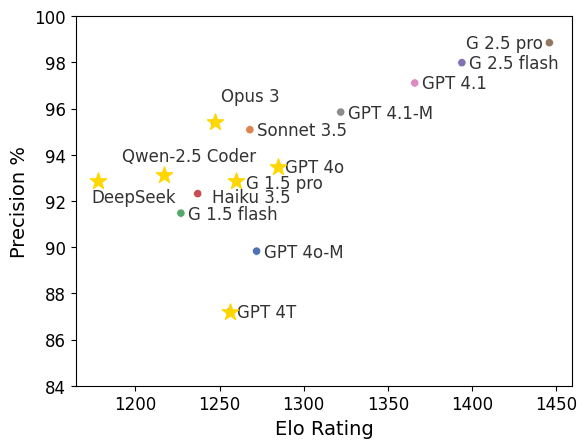

In [10]:
plt.figure()

sns.scatterplot(data=df_plot_rest, x='elo', y='precision', hue='generator', palette='deep')
sns.scatterplot(data=df_plot_human, x='elo', y='precision', hue='generator', palette='deep')
# plt.title('Elo Rating vs Precision')
    
# Add annotations for each point
rows = list(df_plot_human.iterrows()) + list(df_plot_rest.iterrows())
for idx, row in rows:
    shorthand = MODELS_SHORT.get(row['generator'], row['generator'])
    # Use a star symbol for models in MODELS_GEN to indicate "ground truth"
    if row['generator'] in df_pg['generator'].values:
        plt.scatter(row['elo'], row['precision'], color='gold', marker='*', s=150, zorder=4, label='Ground Truth' if idx == 0 else "")
        
    offset = (5, -4) 
    if shorthand in ['Qwen-2.5 Coder']: 
        offset = (-30, 10)
    elif shorthand in ['Opus 3']: 
        offset = (5, 15)
    elif shorthand in ['DeepSeek V2.5']: 
        shorthand = 'DeepSeek'
        offset = (-5, -15)
    elif shorthand in ['Haiku 3.5']: 
        offset = (10, -6)
    elif shorthand in ['G 1.5 pro']: 
        offset = (7, -5)
    elif shorthand in ['G 2.5 pro']:
        offset = (-60, -4)
    plt.annotate(shorthand,  # Use shorthand for model name for clarity
                 xy=(row['elo'], row['precision']),
                 xytext=offset,  # Offset text slightly to the right
                 textcoords='offset points',
                 fontsize=12,
                 alpha=0.8)

plt.ylim(84, 100)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# plt.title('Elo Rating vs Precision', fontsize=16)
plt.xlabel('Elo Rating', fontsize=14)
plt.ylabel('Precision %', fontsize=14)
plt.legend().remove()  # Remove the legend since we have annotations
plt.savefig('../output/images/pdfs/elo_precision.pdf', bbox_inches='tight')


## Elo vs TPR

In [11]:
df_elo_tpr = pd.merge(df_elo, df_tpr, left_on='generator', right_on='validator')
df_plot = df_elo_tpr

df_plot

,generator,elo,validator,tpr
0,gpt-4-turbo,1256,gpt-4-turbo,96.531833
1,gpt-4o-mini,1272,gpt-4o-mini,96.088167
2,gpt-4o,1285,gpt-4o,96.589833
3,claude_3_opus,1247,claude_3_opus,96.240833
4,claude_3.5_sonnet,1268,claude_3.5_sonnet,96.475167
5,gemini-1.5-flash,1227,gemini-1.5-flash,97.678000
6,gemini-1.5-pro,1260,gemini-1.5-pro,96.149333
7,qwen-coder-plus,1217,qwen-coder-plus,94.824333
8,deepseek-chat,1178,deepseek-chat,97.925000
9,claude_3.5_haiku,1237,claude_3.5_haiku,97.101833


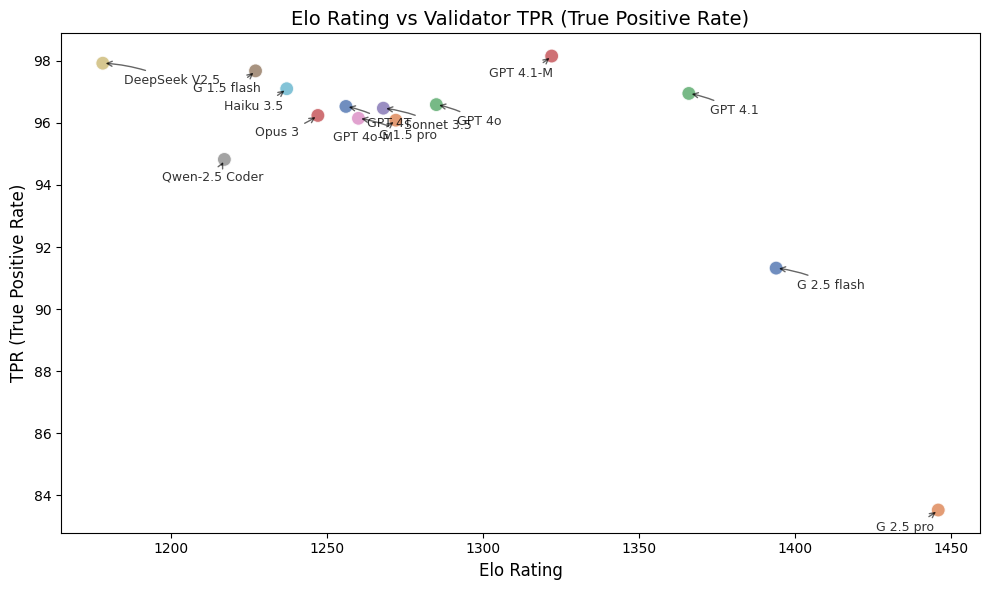

In [12]:
# Create the scatter plot with properly positioned labels
plt.figure(figsize=(10, 6))

# Create the scatterplot without jitter to keep actual data points accurate
sns.scatterplot(
    x='elo', 
    y='tpr', 
    data=df_plot,
    hue='generator', 
    palette='deep',
    s=100,
    alpha=0.8
)

plt.title('Elo Rating vs Validator TPR (True Positive Rate)', fontsize=14)
plt.xlabel('Elo Rating', fontsize=12)
plt.ylabel('TPR (True Positive Rate)', fontsize=12)

# Add annotations with strategic positioning to avoid overlap
for idx, row in df_plot.iterrows():
    shorthand = MODELS_SHORT.get(row['validator'], row['validator'])
    
    # Determine optimal label positioning based on data characteristics
    if row['tpr'] > 0.3:  # Higher TPR models
        y_offset = -15
    else:  # Lower TPR models
        y_offset = 15
    
    # Spread out labels horizontally to reduce overlap
    x_offset = 15 if idx % 2 == 0 else -45
    
    plt.annotate(
        shorthand,
        xy=(row['elo'], row['tpr']),  # Point to exact data point (no jitter)
        xytext=(x_offset, y_offset),  # Offset text for readability
        textcoords='offset points',
        fontsize=9,
        alpha=0.8,
        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.1', alpha=0.6)
    )

plt.legend().remove()  # Remove the legend since we have annotations
plt.tight_layout()


## Elo vs TNR

In [13]:
df_elo_tnr = pd.merge(df_elo, df_tnr, left_on='generator', right_on='validator')
df_plot = df_elo_tnr

df_plot

,generator,elo,validator,tnr
0,gpt-4-turbo,1256,gpt-4-turbo,19.198500
1,gpt-4o-mini,1272,gpt-4o-mini,23.114833
2,gpt-4o,1285,gpt-4o,20.438667
3,claude_3_opus,1247,claude_3_opus,17.761000
4,claude_3.5_sonnet,1268,claude_3.5_sonnet,19.788500
5,gemini-1.5-flash,1227,gemini-1.5-flash,8.013833
6,gemini-1.5-pro,1260,gemini-1.5-pro,17.542667
7,qwen-coder-plus,1217,qwen-coder-plus,23.588000
8,deepseek-chat,1178,deepseek-chat,14.972333
9,claude_3.5_haiku,1237,claude_3.5_haiku,13.804000


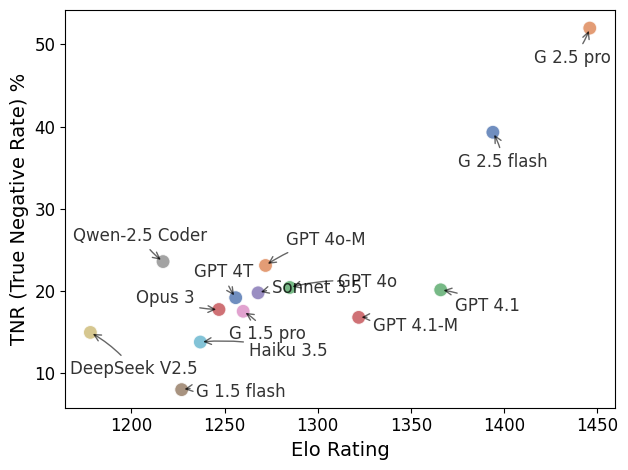

In [14]:
# Create the scatterplot without jitter to keep actual data points accurate
sns.scatterplot(
    x='elo', 
    y='tnr', 
    data=df_plot,
    hue='generator', 
    palette='deep',
    s=100,
    alpha=0.8
)

plt.xlabel('Elo Rating', fontsize=14)
plt.ylabel('TNR (True Negative Rate) %', fontsize=14)

# Improved annotation positioning to avoid overlaps in the 10-30 TNR range and 1200-1300 Elo range
model_offsets = {
    'gpt-4-turbo': (-30, 15),       # Move up and right
    'gpt-4o-mini': (15, 15),      # Move down and right
    'gpt-4o': (35, 0),          # Move down and left
    'claude_3_opus': (-60, 5),    # Move up and left
    'claude_3.5_sonnet': (10, 0),   # Move right
    'gemini-1.5-flash': (10, -5), # Move down and right
    'gemini-1.5-pro': (-10, -20),  # Move down and left
    'qwen-coder-plus': (-65, 15),  # Move up and left
    'deepseek-chat': (-15, -30),   # Move down and left
    'claude_3.5_haiku': (35, -10), # Move down and right
    'gemini-2.5-flash-preview-04-17': (-25, -25), # Keep default
    'gemini-2.5-pro-preview-03-25': (-40, -25),   # Keep default
    'gpt-4.1-2025-04-14': (10, -15),  # Move up and left
    'gpt-4.1-mini-2025-04-14': (10, -10) # Move up and right
}

# Add annotations with custom positioning for each model
for idx, row in df_plot.iterrows():
    shorthand = MODELS_SHORT.get(row['validator'], row['validator'])
    
    # Get the custom offset for this model
    x_offset, y_offset = model_offsets.get(row['validator'], (15, 15))
    
    plt.annotate(
        shorthand,
        xy=(row['elo'], row['tnr']),  # Point to exact data point
        xytext=(x_offset, y_offset),  # Use custom offset
        textcoords='offset points',
        fontsize=12,
        alpha=0.8,
        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.1', alpha=0.6)
    )
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend().remove()  # Remove the legend since we have annotations
plt.tight_layout()
plt.savefig('../output/images/pdfs/elo_tnr.pdf', bbox_inches='tight')

# Generator vs Validator

In [15]:
df_gen_valid = pd.merge(df[df['validator'] == 'ensemble'], df_tpr, left_on='generator', right_on='validator')
# Drop existing model_x column to avoid confusion when merging
df_gen_valid.drop(['validator_x'], axis=1, inplace=True)
df_gen_valid.drop(['validator_y'], axis=1, inplace=True)
df_gen_valid = pd.merge(df_gen_valid, df_tnr, left_on='generator', right_on='validator')

df_gen_valid

,generator,precision,tpr,validator,tnr
0,gpt-4-turbo,85.029,96.531833,gpt-4-turbo,19.198500
1,gpt-4o-mini,89.827,96.088167,gpt-4o-mini,23.114833
2,gpt-4o,95.158,96.589833,gpt-4o,20.438667
3,claude_3_opus,93.793,96.240833,claude_3_opus,17.761000
4,claude_3.5_sonnet,95.083,96.475167,claude_3.5_sonnet,19.788500
5,gemini-1.5-flash,91.472,97.678000,gemini-1.5-flash,8.013833
6,gemini-1.5-pro,93.089,96.149333,gemini-1.5-pro,17.542667
7,qwen-coder-plus,89.709,94.824333,qwen-coder-plus,23.588000
8,deepseek-chat,90.918,97.925000,deepseek-chat,14.972333
9,claude_3.5_haiku,92.315,97.101833,claude_3.5_haiku,13.804000


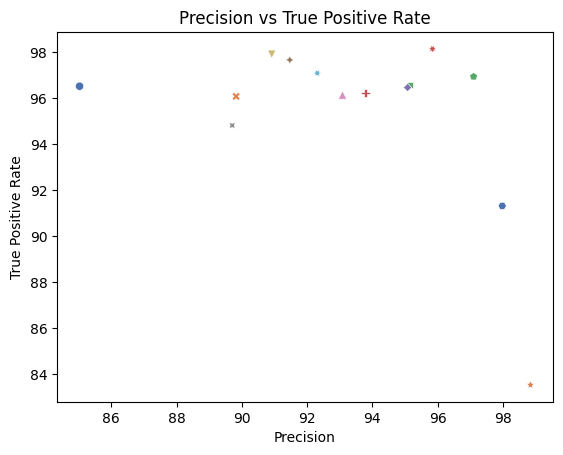

In [16]:
sns.scatterplot(data=df_gen_valid, x='precision', y='tpr', hue='generator', style='generator', palette='deep')

plt.title('Precision vs True Positive Rate')
plt.xlabel('Precision')
plt.ylabel('True Positive Rate')
# Add annotations for each point
for idx, row in df_gen_valid.iterrows():
    shorthand = MODELS_SHORT.get(row['generator'], row['generator'])

    # Determine optimal label positioning based on data characteristics
    if row['tpr'] > 0.5:  # Higher TPR models
        y_offset = -5
    else:  # Lower TPR models
        y_offset = 5

    # Spread out labels horizontally to reduce overlap
    x_offset = 5 if idx % 2 == 0 else -5
    # plt.annotate(
    #     shorthand,
    #     xy=(row['precision'], row['tnr']),  # Point to exact data point (no jitter)
    #     xytext=(x_offset, y_offset),  # Offset text for readability
    #     textcoords='offset points',
    #     fontsize=9,
    #     alpha=0.8,
    #     arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.1', alpha=0.6)
    # )
    
    
plt.legend().remove()  # Remove the legend since we have annotations
# plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')

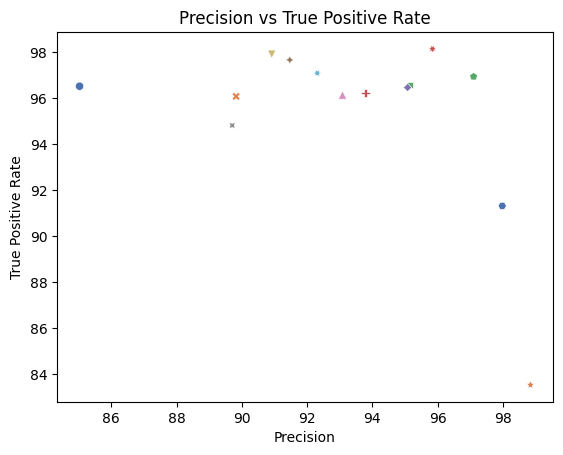

In [17]:
sns.scatterplot(data=df_gen_valid, x='precision', y='tpr', hue='generator', style='generator', palette='deep')

plt.title('Precision vs True Positive Rate')
plt.xlabel('Precision')
plt.ylabel('True Positive Rate')
# Add annotations for each point
for idx, row in df_gen_valid.iterrows():
    shorthand = MODELS_SHORT.get(row['generator'], row['generator'])

    # Determine optimal label positioning based on data characteristics
    if row['tpr'] > 0.5:  # Higher TPR models
        y_offset = -5
    else:  # Lower TPR models
        y_offset = 5

    # Spread out labels horizontally to reduce overlap
    x_offset = 5 if idx % 2 == 0 else -5
    # plt.annotate(
    #     shorthand,
    #     xy=(row['precision'], row['tnr']),  # Point to exact data point (no jitter)
    #     xytext=(x_offset, y_offset),  # Offset text for readability
    #     textcoords='offset points',
    #     fontsize=9,
    #     alpha=0.8,
    #     arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.1', alpha=0.6)
    # )
    
    
plt.legend().remove()  # Remove the legend since we have annotations
# plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')

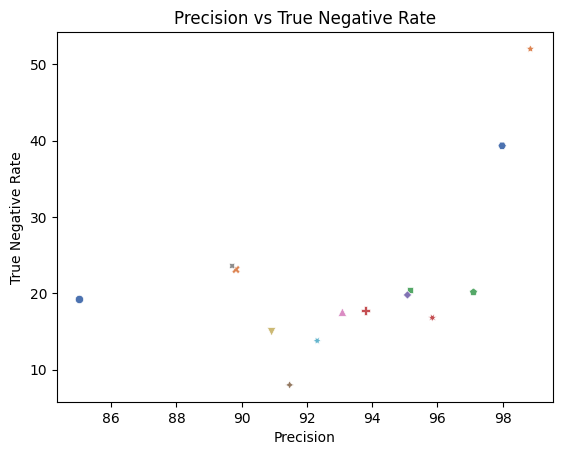

In [18]:
sns.scatterplot(data=df_gen_valid, x='precision', y='tnr', hue='generator', style='generator', palette='deep')

plt.title('Precision vs True Negative Rate')
plt.xlabel('Precision')
plt.ylabel('True Negative Rate')
# Add annotations for each point
for idx, row in df_gen_valid.iterrows():
    shorthand = MODELS_SHORT.get(row['generator'], row['generator'])

    # Determine optimal label positioning based on data characteristics
    if row['tpr'] > 0.5:  # Higher TPR models
        y_offset = -5
    else:  # Lower TPR models
        y_offset = 5

    # Spread out labels horizontally to reduce overlap
    x_offset = 5 if idx % 2 == 0 else -5
    # plt.annotate(
    #     shorthand,
    #     xy=(row['precision'], row['tnr']),  # Point to exact data point (no jitter)
    #     xytext=(x_offset, y_offset),  # Offset text for readability
    #     textcoords='offset points',
    #     fontsize=9,
    #     alpha=0.8,
    #     arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.1', alpha=0.6)
    # )
    
    
plt.legend().remove()  # Remove the legend since we have annotations
# plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')

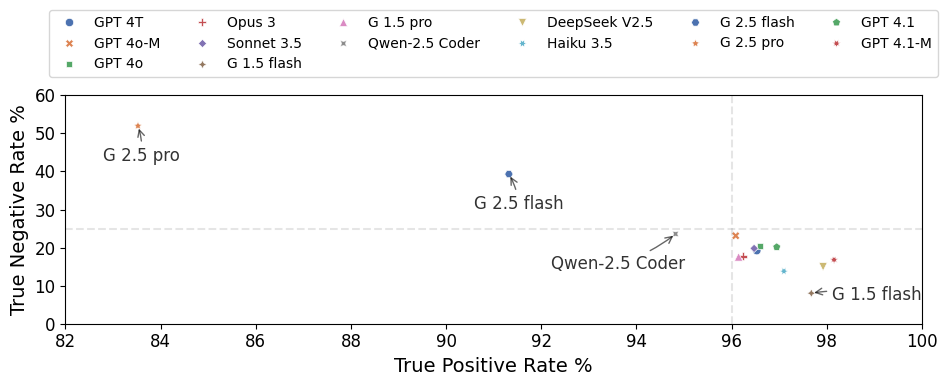

In [19]:

plt.figure(figsize=(10, 4))
sns.scatterplot(data=df_gen_valid, x='tpr', y='tnr', hue='generator', style='generator', palette='deep')

# plt.title('True Positive Rate vs True Negative Rate')
plt.xlabel('True Positive Rate %', fontsize=14)
plt.ylabel('True Negative Rate %', fontsize=14)

# Improved annotation positioning to avoid overlaps in the 10-30 TNR range and 1200-1300 Elo range
model_offsets = {
    'gpt-4-turbo': (-30, 10),       # Move up and right
    'gemini-1.5-flash': (15, -5), # Move down and right

    'gpt-4o-mini': (10, -5),      # Move down and right
    'gpt-4o': (30, 10),          # Move down and left
    'claude_3_opus': (-20, -65),    # Move up and left
    'claude_3.5_sonnet': (40, -65),   # Move right
    
    'gemini-1.5-pro': (-10, -30),  # Move down and left
    'qwen-coder-plus': (-90, -25),  # Move up and left
    'deepseek-chat': (-45, -60),   # Move down and left
    'claude_3.5_haiku': (-45, -30), # Move down and right
    'gpt-4.1-2025-04-14': (-256, -15),  # Move up and left
    'gpt-4.1-mini-2025-04-14': (-250, -10), # Move up and right

    'gemini-2.5-flash-preview-04-17': (-25, -25), # Keep default
    'gemini-2.5-pro-preview-03-25': (-25, -25),   # Keep default
}    

# Add annotations for each point
for idx, row in df_gen_valid.iterrows():
    shorthand = MODELS_SHORT.get(row['generator'], row['generator'])
    x_offset, y_offset = model_offsets.get(row['generator'], (0, 0))
    
    if shorthand in ['G 1.5 flash', 'G 2.5 pro', 'G 2.5 flash', 'Qwen-2.5 Coder']: 
        
        # Add arrow pointing to the marker
        plt.annotate(shorthand,
                        xy=(row['tpr'], row['tnr']), 
                        xytext=(x_offset, y_offset),
                        textcoords='offset points',
                        fontsize=12,
                        alpha=0.8,
                        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.1', alpha=0.6))

plt.axhline(y=25, color='gray', linestyle='--', alpha=0.2)
plt.axvline(x=96, color='gray', linestyle='--', alpha=0.2)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0,60)
plt.xlim(82,100)
# Use shorthand names for the legend instead of full model names
handles, labels = plt.gca().get_legend_handles_labels()
shorthand_labels = [MODELS_SHORT.get(label, label) for label in labels]
plt.legend(handles, shorthand_labels,  bbox_to_anchor=(0.5, 1.05), loc='lower center', ncol=6)
plt.tight_layout()
plt.savefig('../output/images/pdfs/tpr_tnr.pdf', bbox_inches='tight')

# GV Plot

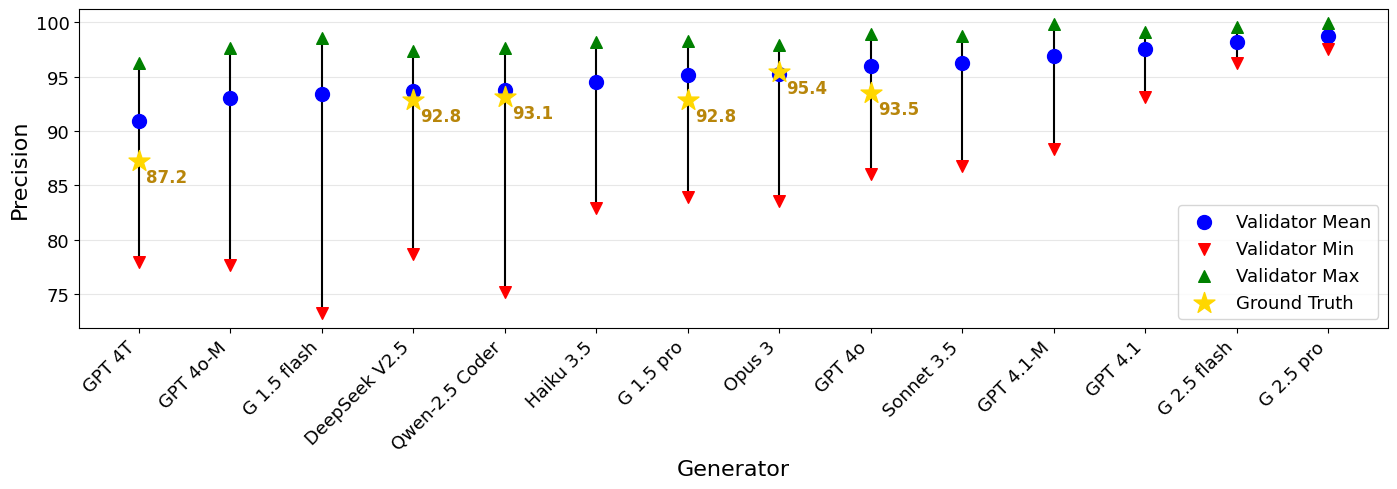

In [20]:
df_gv

# Create a figure
plt.figure(figsize=(14, 5))

# Group by generator to get statistics for each
grouped = df_gv.groupby('generator')
stats = grouped.agg({'precision': ['mean', 'min', 'max']})
stats.columns = ['mean', 'min', 'max']
stats = stats.reset_index()

# Sort by mean precision for better visualization
stats = stats.sort_values('mean', ascending=True)

# Plot vertical lines from min to max
for i, row in enumerate(stats.itertuples()):
    plt.plot([i, i], [row.min, row.max], 'k-', linewidth=1.5)
    
# Plot mean markers
plt.scatter(range(len(stats)), stats['mean'], color='blue', s=100, zorder=3, label='Validator Mean')
plt.scatter(range(len(stats)), stats['min'], color='red', s=70, zorder=3, marker='v', label='Validator Min')
plt.scatter(range(len(stats)), stats['max'], color='green', s=70, zorder=3, marker='^', label='Validator Max')

# Add a scatter for human ground truth evaluations from df_pg
for i, row in df_pg.iterrows():
    # Find the position in stats dataframe
    gen_idx = stats[stats['generator'] == row['generator']].index
    if len(gen_idx) > 0:
        idx = stats.index.get_loc(gen_idx[0])
        plt.scatter([idx], [row['precision']], color='gold', marker='*', s=250, zorder=4, 
                    label='Ground Truth' if i == 0 else "")
        
        # Add annotation for the human evaluation with precision multiplied by 100
        plt.annotate(f"{row['precision']:.1f}", 
                     xy=(idx, row['precision']), 
                     xytext=(20, -15),  # Offset below the point
                     textcoords='offset points', 
                     ha='center', 
                     color='darkgoldenrod',
                     fontweight='bold',
                     fontsize=12)

# Set x-tick labels to model names, using shorthand for readability
plt.xticks(range(len(stats)), [MODELS_SHORT.get(model, model) for model in stats['generator']], 
           rotation=45, ha='right', fontsize=13)

plt.ylabel('Precision', fontsize=16)
plt.xlabel('Generator', fontsize=16)
plt.grid(True, axis='y', alpha=0.3)
# plt.title('Generator Precision by Different Validators', fontsize=18, pad=15)
plt.legend(fontsize=13)
plt.tight_layout()

# Increase the size of tick labels
plt.yticks(fontsize=13)

# Save with high DPI for crisp text
plt.savefig('../output/images/pdfs/gv.pdf', bbox_inches='tight')

# 

# Error plots

# Pricing 

In [21]:
# Create the scatter plot with log scale on x-axis
plt.figure(figsize=(10, 6))
plt.scatter(df['pricing'], df['pG'], alpha=0.7, s=100)
# Add labels for each point with offset based on model positions
offsets = {
    'gpt-3.5-turbo': (-20, -15),
    'gpt-4-turbo': (10, 5),
    'gpt-4o-mini': (-40, -5),
    'gpt-4o': (10, 10),
    'claude_3_opus': (10, -10),
    'claude_3.5_sonnet': (-30, 15),
    'gemini-1.5-flash': (-80, -10),
    'gemini-1.5-pro': (10, -15),
    'qwen-coder-plus': (-30, 20),
    'deepseek-chat': (15, 10)
}

for i, model in enumerate(df['model']):
    plt.annotate(model, 
                (df['pricing'].iloc[i], df['pG'].iloc[i]),
                xytext=offsets[model], 
                textcoords='offset points',
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.1', alpha=0.7))

# Add title and labels
plt.title('Generator Precision (ensemble) vs Pricing', fontsize=14)
plt.xlabel('Price per 1M output tokens (log scale)', fontsize=12)
plt.ylabel('Generator Precision', fontsize=12)
plt.grid(True, alpha=0.3)

# Set x-axis to log scale
plt.xscale('log')

# Set x-axis limits from 10^0 to 10^2
plt.xlim(100, 0.1)  # Flipped the order to go from high to low
plt.ylim(0.9, 1.0)

plt.tight_layout()
plt.show()


KeyError: 'pricing'

<Figure size 1000x600 with 0 Axes>

# Loss ablation

## Loss plots

In [ ]:
def plot_loss(k=2, method='BFGS', lossGV='crossEntropy', lossOthers='RMSE', weights=[], ylim=1e-3):
    weightGV, weightG, weightVV, weightVIV = weights
    weightsStr = '-'.join(map(str, weights))
    df = pd.read_csv(f'../output/logs/loss iteration/{method}_{lossGV}_{lossOthers}_{weightsStr}.csv')
    
    plt.figure(figsize=(12, 6))

    # Get the last values for annotations
    last_iter = df['iter'].iloc[-1]
    last_train_loss_GV = df['train_loss_GV'].iloc[-1]
    last_train_loss_g = df['train_loss_g'].iloc[-1]
    last_train_loss_vv = df['train_loss_vv'].iloc[-1]
    last_train_loss_viv = df['train_loss_viv'].iloc[-1]
    last_test_loss_g = df['test_loss_g'].iloc[-1]

    # Plot all training losses with solid lines
    plt.plot(df['iter'], df['train_loss_GV'], color='green', linewidth=2, label=f'GV ({weightGV}x)')
    plt.plot(df['iter'], df['train_loss_vv'], color='purple', linewidth=2, label=f'V+ ({weightVV}x)')
    plt.plot(df['iter'], df['train_loss_viv'], color='orange', linewidth=2, label=f'V- ({weightVIV}x)')
    plt.plot(df['iter'], df['test_loss_g'], color='red', linewidth=2, linestyle='--', label='G Test')
    plt.plot(df['iter'], df['train_loss_g'], color='blue', linewidth=2, label=f'G Train ({weightG}x)')

    # Add annotations for the final values
    plt.annotate(f'{last_train_loss_GV:.6f}', xy=(last_iter, last_train_loss_GV), 
                 xytext=(last_iter + 50, last_train_loss_GV), color='green')
    
    plt.annotate(f'{last_train_loss_vv:.6f}', xy=(last_iter, last_train_loss_vv), 
                 xytext=(last_iter + 50, last_train_loss_vv), color='purple')
    
    plt.annotate(f'{last_train_loss_viv:.6f}', xy=(last_iter, last_train_loss_viv), 
                 xytext=(last_iter + 50, last_train_loss_viv), color='orange')
    
    plt.annotate(f'{last_test_loss_g:.6f}', xy=(last_iter, last_test_loss_g), 
                 xytext=(last_iter + 50, last_test_loss_g), color='red')
    
    plt.annotate(f'{last_train_loss_g:.6f}', xy=(last_iter, last_train_loss_g), 
                 xytext=(last_iter + 50, last_train_loss_g), color='blue')

    # Add labels and title
    plt.xlabel('Iterations', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title(f'k={k} method={method} lossGV={lossGV} lossOthers={lossOthers}', fontsize=14)

    # Add grid and legend
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)

    # Use log scale for y-axis as the loss values span several orders of magnitude
    plt.yscale('log')

    # Add some padding to the x-axis to make room for annotations
    plt.xlim(0, last_iter + 350)
    plt.ylim(ylim, 1)

    plt.tight_layout()
    plt.show()

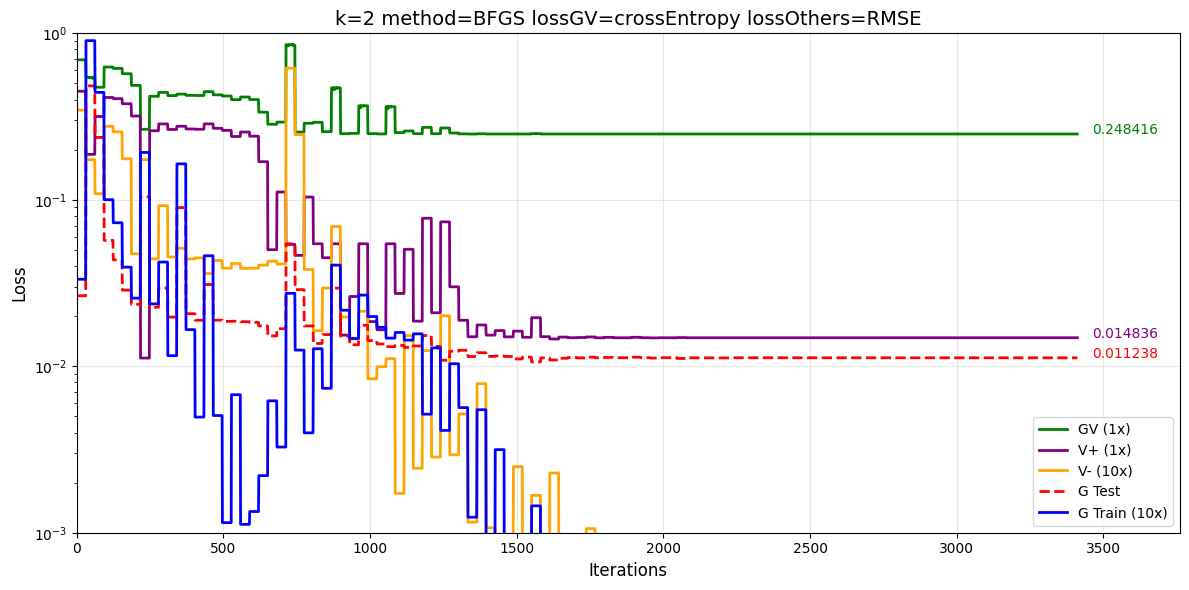

In [ ]:
plot_loss(k=2, method='BFGS', lossGV='crossEntropy', lossOthers='RMSE', weights=[1, 10, 1, 10])

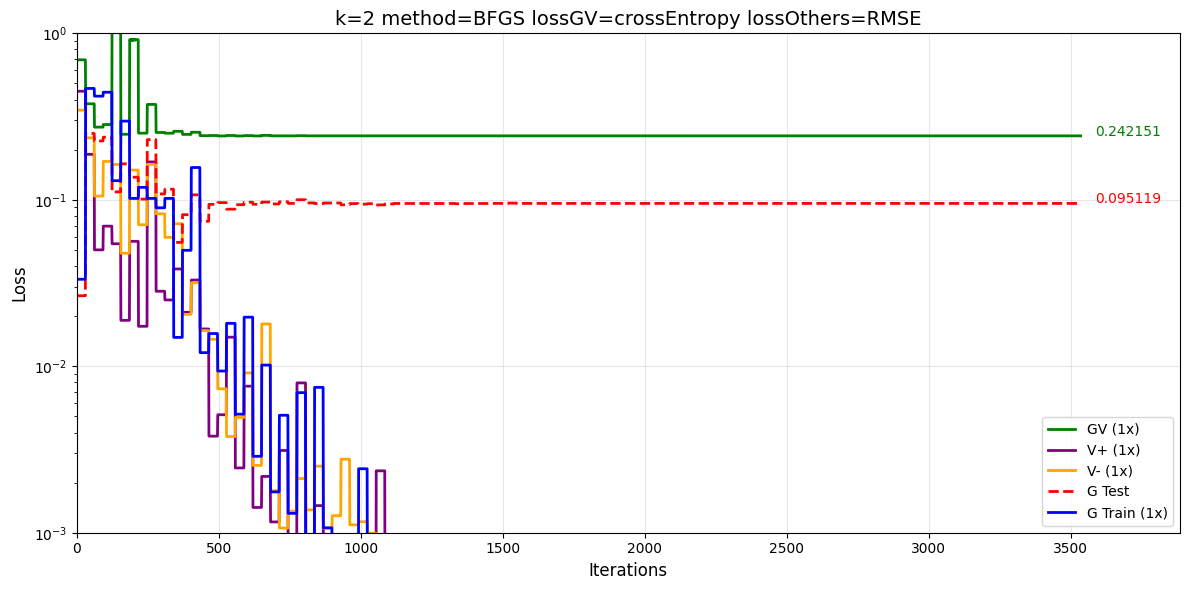

In [ ]:
plot_loss(k=2, method='BFGS', lossGV='crossEntropy', lossOthers='RMSE', weights=[1, 1, 1, 1])

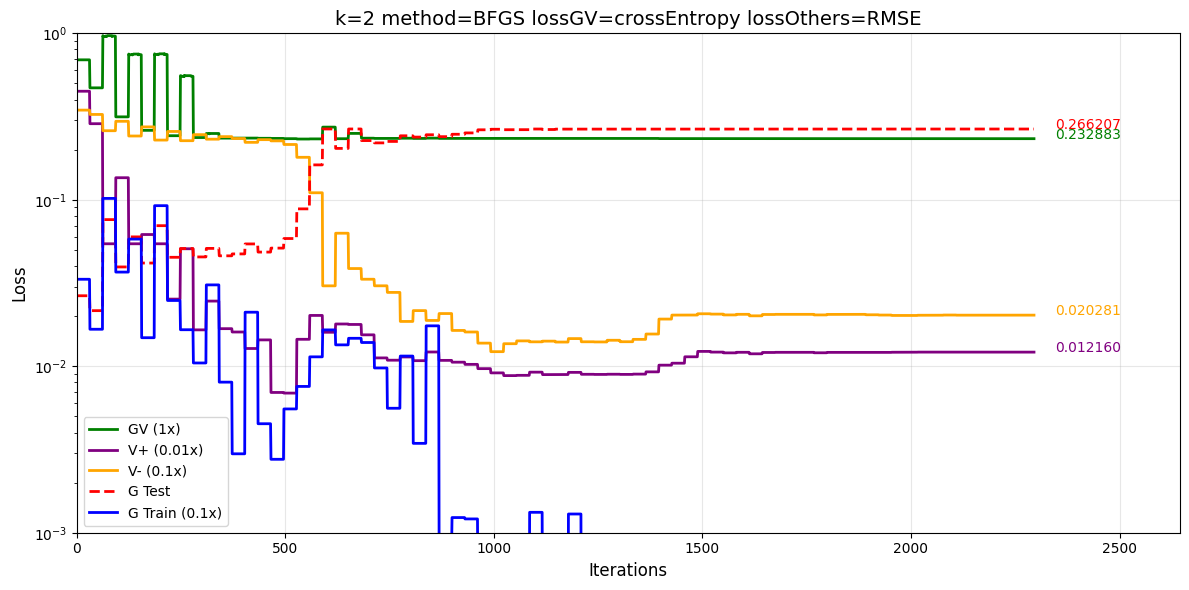

In [ ]:

plot_loss(k=2, method='BFGS', lossGV='crossEntropy', lossOthers='RMSE', weights=[1, 0.1, 0.01, 0.1])

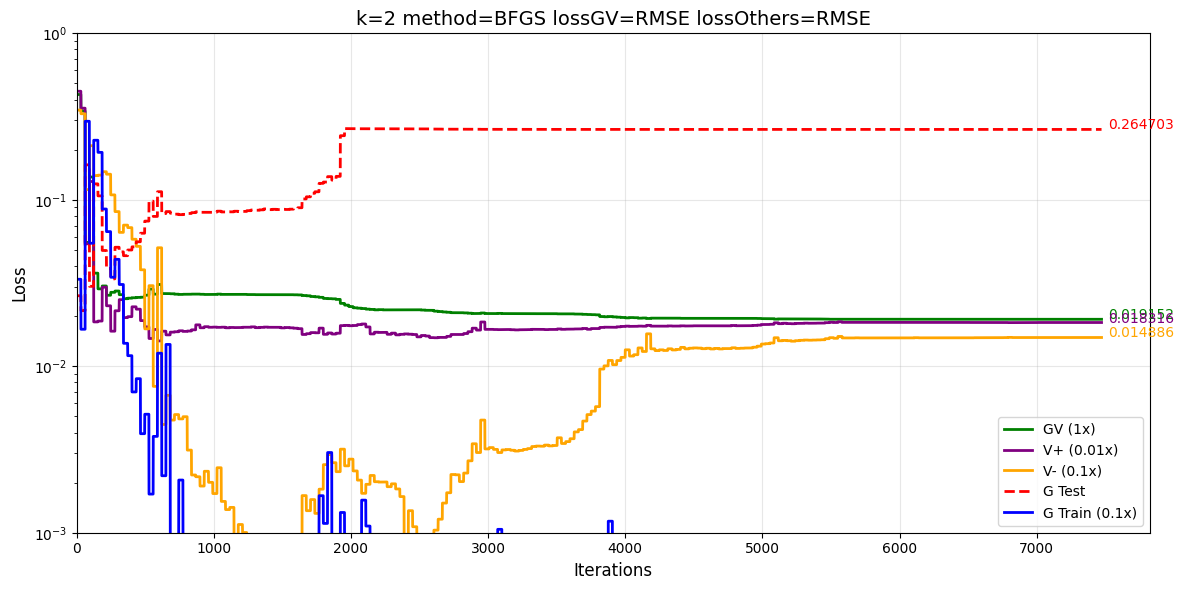

In [ ]:

plot_loss(k=2, method='BFGS', lossGV='RMSE', lossOthers='RMSE', weights=[1, 0.1, 0.01, 0.1])

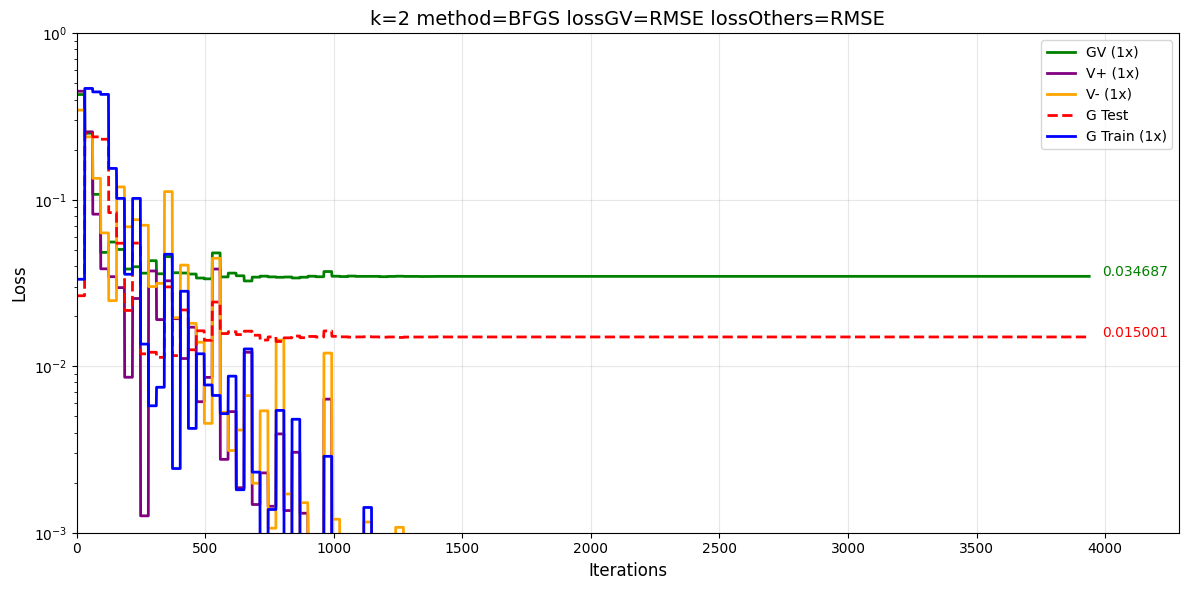

In [ ]:

plot_loss(k=2, method='BFGS', lossGV='RMSE', lossOthers='RMSE', weights=[1, 1, 1, 1])

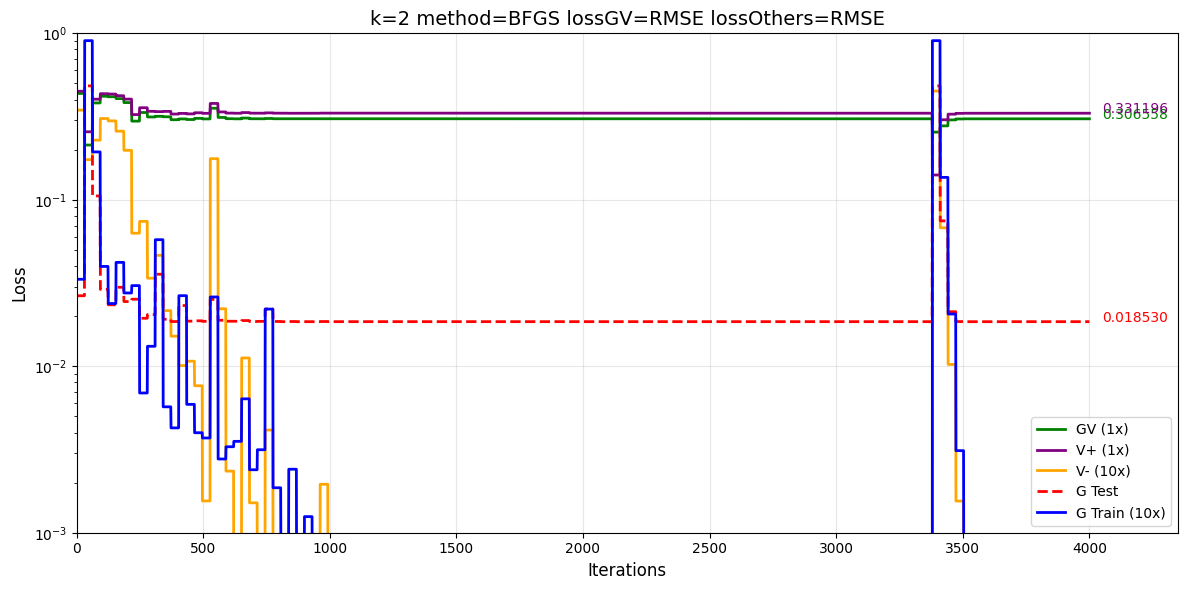

In [ ]:

plot_loss(k=2, method='BFGS', lossGV='RMSE', lossOthers='RMSE', weights=[1, 10, 1, 10])

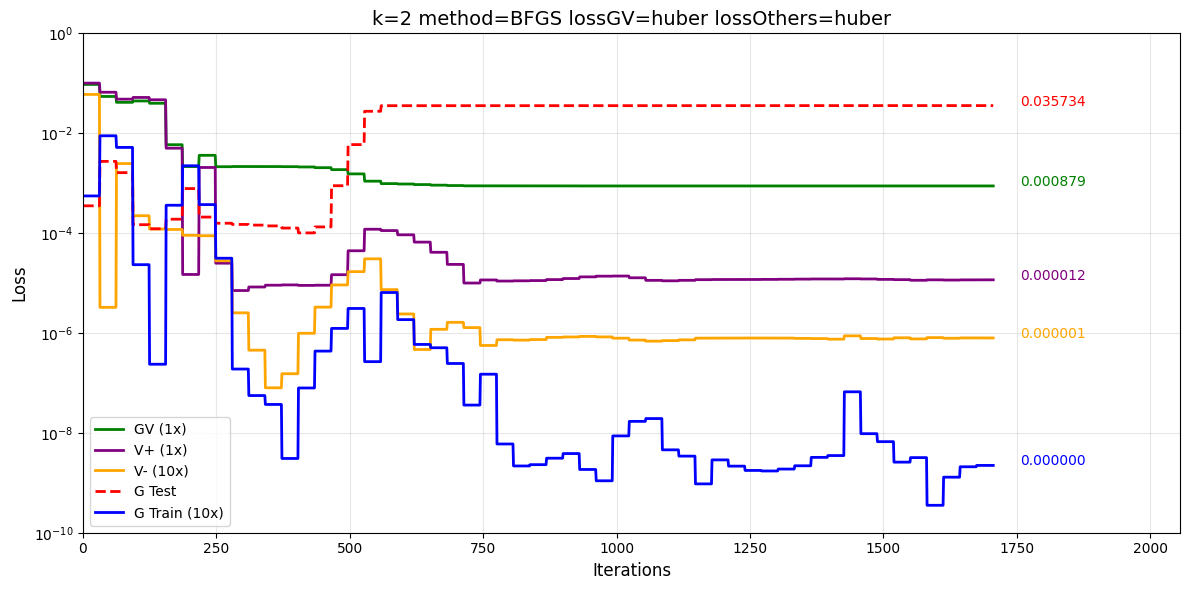

In [ ]:
plot_loss(k=2, method='BFGS', lossGV='huber', lossOthers='huber', weights=[1, 10, 1, 10], ylim=1e-10)

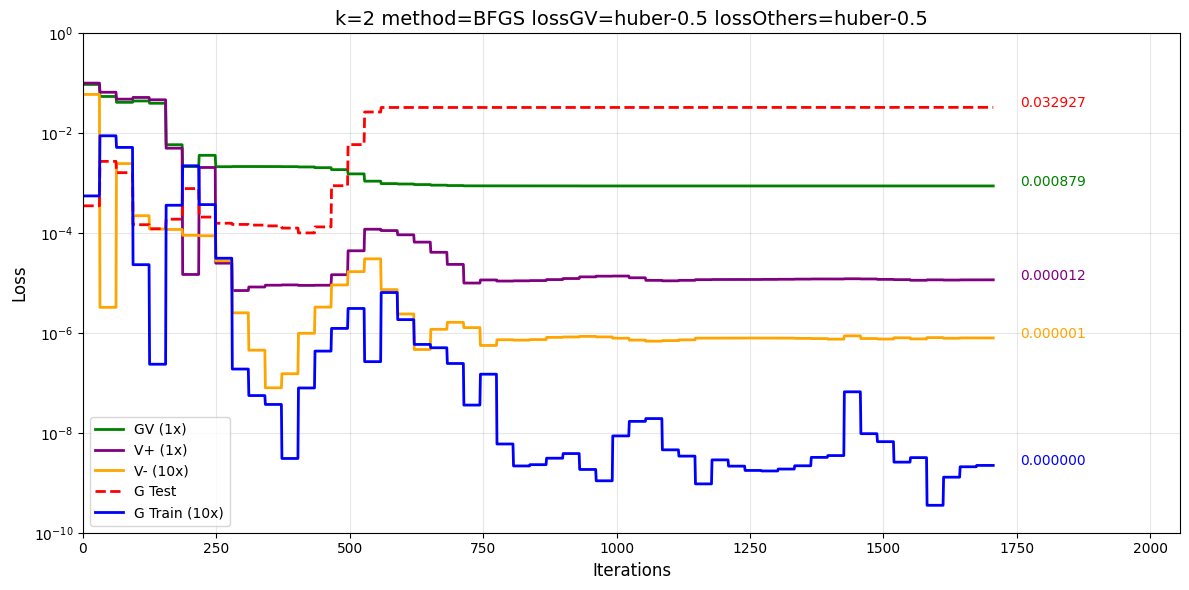

In [ ]:
plot_loss(k=2, method='BFGS', lossGV='huber-0.5', lossOthers='huber-0.5', weights=[1, 10, 1, 10], ylim=1e-10)

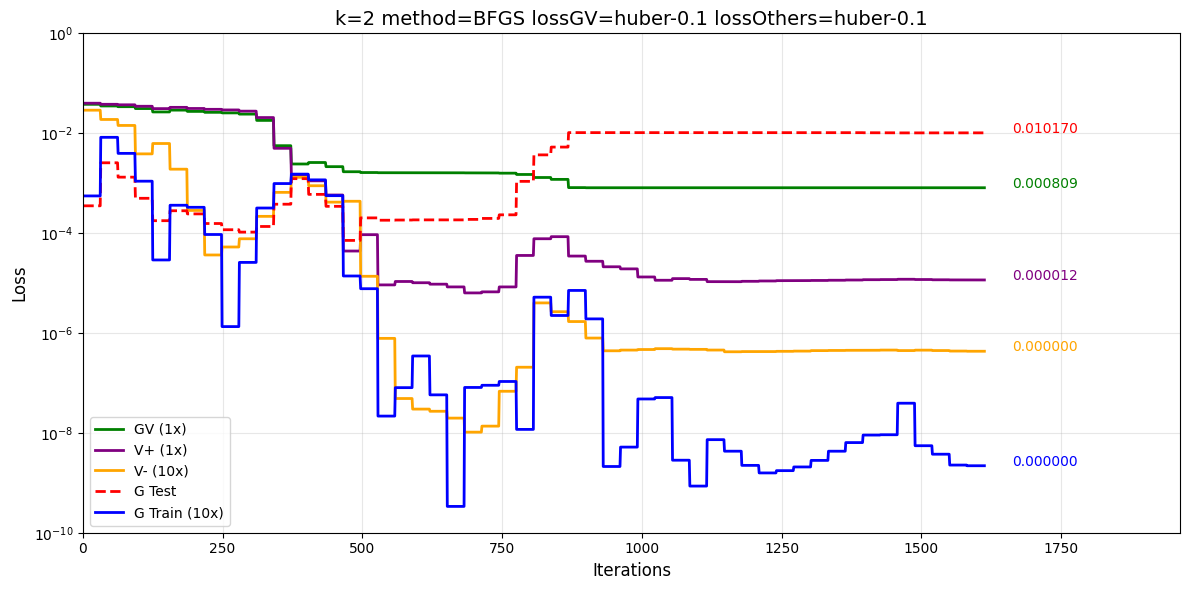

In [ ]:
plot_loss(k=2, method='BFGS', lossGV='huber-0.1', lossOthers='huber-0.1', weights=[1, 10, 1, 10], ylim=1e-10)

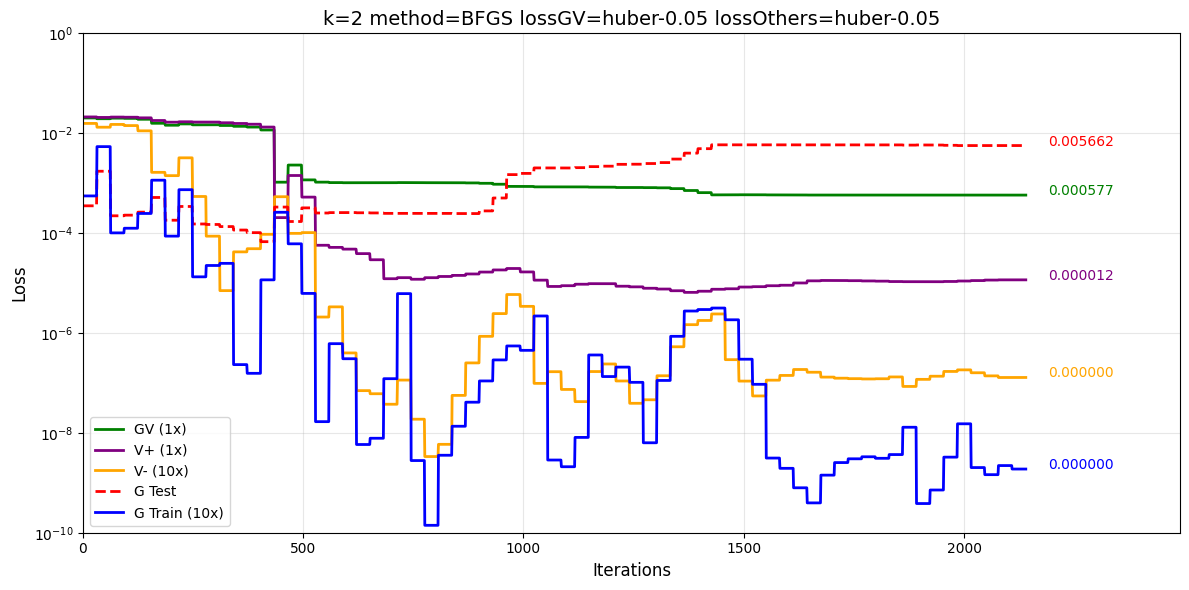

In [ ]:
plot_loss(k=2, method='BFGS', lossGV='huber-0.05', lossOthers='huber-0.05', weights=[1, 10, 1, 10], ylim=1e-10)

# Ben's plots

## Release date helpers

In [24]:
releaseDates = {
    'gpt-4-turbo': '2023-11-01',
    'gpt-4o': '2024-05-13',
    'gpt-4o-mini': '2024-07-18',
    'gpt-4.1-2025-04-14': '2025-05-14',
    'gpt-4.1-mini-2025-04-14': '2025-05-14',
    'claude_3_opus': '2024-02-29',
    'claude_3.5_sonnet': '2024-06-20',
    'claude_3.5_haiku': '2024-10-22',
    'gemini-1.5-flash': '2024-05-10',
    'gemini-1.5-pro': '2024-04-09',
    'gemini-2.5-flash-preview-04-17': '2025-04-17',
    'gemini-2.5-pro-preview-03-25': '2025-03-25',
    MODEL_QWEN: '2024-11-06',
    MODEL_DEEPSEEK: '2024-12-10',
}

versionDates = {
    'gpt-4-turbo': '2024-04-09',
    'gpt-4o': '2025-01-29',
    'gpt-4o-mini': '2024-11-05',
    'gpt-4.1-2025-04-14': '2025-05-14',
    'gpt-4.1-mini-2025-04-14': '2025-05-14',
    'claude_3_opus': '2024-02-29',
    'claude_3.5_sonnet': '2024-10-22',
    'claude_3.5_haiku': '2024-10-22',
    'gemini-1.5-flash': '2024-09-01',
    'gemini-1.5-pro': '2024-09-01',
    'gemini-2.5-flash-preview-04-17': '2025-04-17',
    'gemini-2.5-pro-preview-03-25': '2025-05-06',
    MODEL_QWEN: '2024-11-06',
    MODEL_DEEPSEEK: '2024-12-10',
}

In [25]:
# Create a dataframe with model data, precision values, and dates
model_data = []

for model in MODELS:
    # Get the actual precision (ground truth) if available, otherwise use None
    precision_actual = pGa_CONST.get(model, None)
    if precision_actual is not None:
        precision_actual *= 100  # Convert to percentage
    
    # Get the predicted precision from ensemble
    precision_predicted = pEnsemble.get(model, None)
    if precision_predicted is not None:
        precision_predicted *= 100  # Convert to percentage
    
    # Get dates
    release_date = releaseDates.get(model, None)
    version_date = versionDates.get(model, None)
    
    model_data.append({
        'model': model,
        'precision-actual': precision_actual,
        'precision-predicted': precision_predicted,
        'release-date': release_date,
        'version-date': version_date
    })

# Create DataFrame
df_model_info = pd.DataFrame(model_data)

# Convert date strings to datetime objects
df_model_info['release-date'] = pd.to_datetime(df_model_info['release-date'])
df_model_info['version-date'] = pd.to_datetime(df_model_info['version-date'])

# Display the dataframe
df_model_info

,model,precision-actual,precision-predicted,release-date,version-date
0,gpt-4-turbo,87.200,87.314,2023-11-01,2024-04-09
1,gpt-4o-mini,NaN,90.031,2024-07-18,2024-11-05
2,gpt-4o,93.478,95.158,2024-05-13,2025-01-29
3,claude_3_opus,95.402,93.793,2024-02-29,2024-02-29
4,claude_3.5_sonnet,NaN,95.083,2024-06-20,2024-10-22
5,gemini-1.5-flash,NaN,93.341,2024-05-10,2024-09-01
6,gemini-1.5-pro,92.846,93.902,2024-04-09,2024-09-01
7,qwen-coder-plus,93.117,89.821,2024-11-06,2024-11-06
8,deepseek-chat,92.841,91.109,2024-12-10,2024-12-10
9,claude_3.5_haiku,NaN,92.412,2024-10-22,2024-10-22


## Generator precision over time

In [33]:
def plot_precision_over_time(df_info, date_col='release-date', x_label='Model Release Date', 
                       file_path='../output/images/pdfs/precision_over_time.pdf', title=None):
    """
    Create a scatter plot showing precision over time (using a specified date column).
    
    Parameters:
    -----------
    df_info : pandas.DataFrame
        DataFrame containing model information with precision and date columns
    date_col : str
        Column name for the date to plot on x-axis (default: 'release-date')
    x_label : str
        Label for the x-axis (default: 'Model Release Date')
    file_path : str
        Path to save the plot as PDF (default: '../output/images/pdfs/precision_over_time.pdf')
    title : str
        Title for the plot (default: None, which generates an automatic title)
    """
    plt.figure(figsize=(12, 8))

    # Use all models with predicted precision
    df_plot = df_info.dropna(subset=['precision-predicted']).copy()
    
    # Sort by the chosen date column for better visualization
    df_plot = df_plot.sort_values(date_col)

    # Plot predicted precision points
    sns.scatterplot(
        x=date_col, 
        y='precision-predicted', 
        data=df_plot,
        hue='model',
        palette='deep',
        s=100,
        alpha=0.8
    )

    # Plot actual precision points as golden stars (only where available)
    for _, row in df_plot.iterrows():
        if pd.notna(row['precision-actual']):
            # Plot the golden star for actual precision
            plt.scatter(
                x=row[date_col], 
                y=row['precision-actual'],
                color='gold',
                marker='*',
                s=250,
                zorder=5,
                edgecolor='black',
                linewidth=0.5
            )
            
            # Draw lines connecting actual and predicted values
            plt.plot(
                [row[date_col], row[date_col]], 
                [row['precision-actual'], row['precision-predicted']],
                'k-',
                alpha=0.6,
                linestyle='--',
                linewidth=1
            )

    # Add model name annotations next to points
    for _, row in df_plot.iterrows():
        shorthand = MODELS_SHORT.get(row['model'], row['model'])
        # Position the label to the right of the point
        plt.annotate(
            shorthand,
            xy=(row[date_col], row['precision-predicted']),
            xytext=(7, 0),  # Offset text to the right
            textcoords='offset points',
            fontsize=10,
            alpha=0.8
        )

    # Format the x-axis to show dates nicely
    plt.gcf().autofmt_xdate()
    date_format = plt.matplotlib.dates.DateFormatter('%b %Y')
    plt.gca().xaxis.set_major_formatter(date_format)

    # Add a legend entry for the actual precision (golden star)
    from matplotlib.lines import Line2D
    custom_legend = [Line2D([0], [0], marker='*', color='w', markerfacecolor='gold', 
                        markersize=15, label='Actual Precision', markeredgecolor='black', markeredgewidth=0.5)]

    # Get current handles and labels
    handles, labels = plt.gca().get_legend_handles_labels()

    # Remove the default legend
    plt.legend().remove()

    # Create a new legend combining both
    plt.legend(handles=custom_legend, loc='lower right', fontsize=10)

    # Add labels and title
    plt.xlabel(x_label, fontsize=14)
    plt.ylabel('Precision (%)', fontsize=14)
    
    # Set title if provided, otherwise create a default one
    if title is None:
        title = f'Model Precision Over Time: Actual vs Predicted (by {date_col})'
    plt.title(title, fontsize=16)

    # Set y-axis limits to focus on the relevant range
    plt.ylim(85, 100)

    # Add grid for better readability
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(file_path, bbox_inches='tight')
    
    return df_plot  # Return the filtered dataframe used for plotting

/var/folders/w9/mjx_cxyd3nsd2l35mkr5lckh0000gn/T/ipykernel_42353/2149103816.py:54: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(


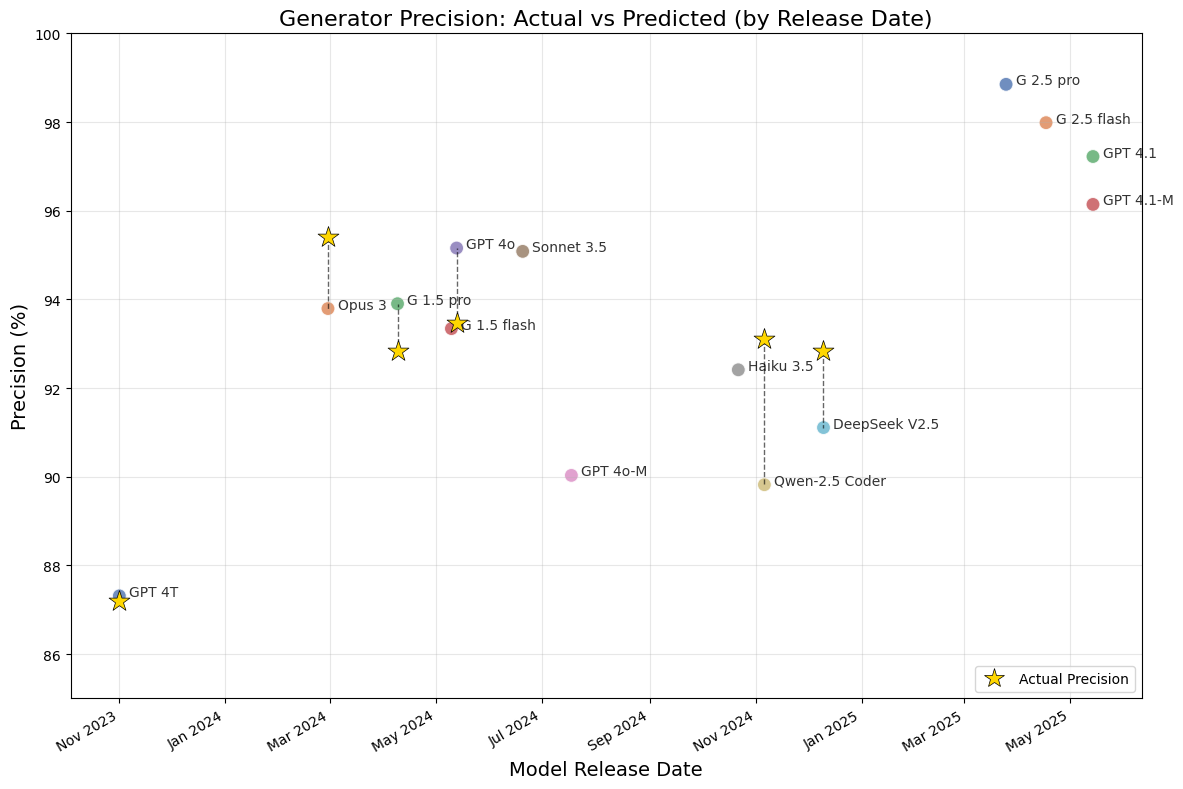

In [37]:
df_plot = plot_precision_over_time(
    df_model_info,
    date_col='release-date',
    x_label='Model Release Date',
    file_path='../output/images/pdfs/precision_by_release_date.pdf',
    title='Generator Precision: Actual vs Predicted (by Release Date)'
)

/var/folders/w9/mjx_cxyd3nsd2l35mkr5lckh0000gn/T/ipykernel_42353/2149103816.py:54: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(


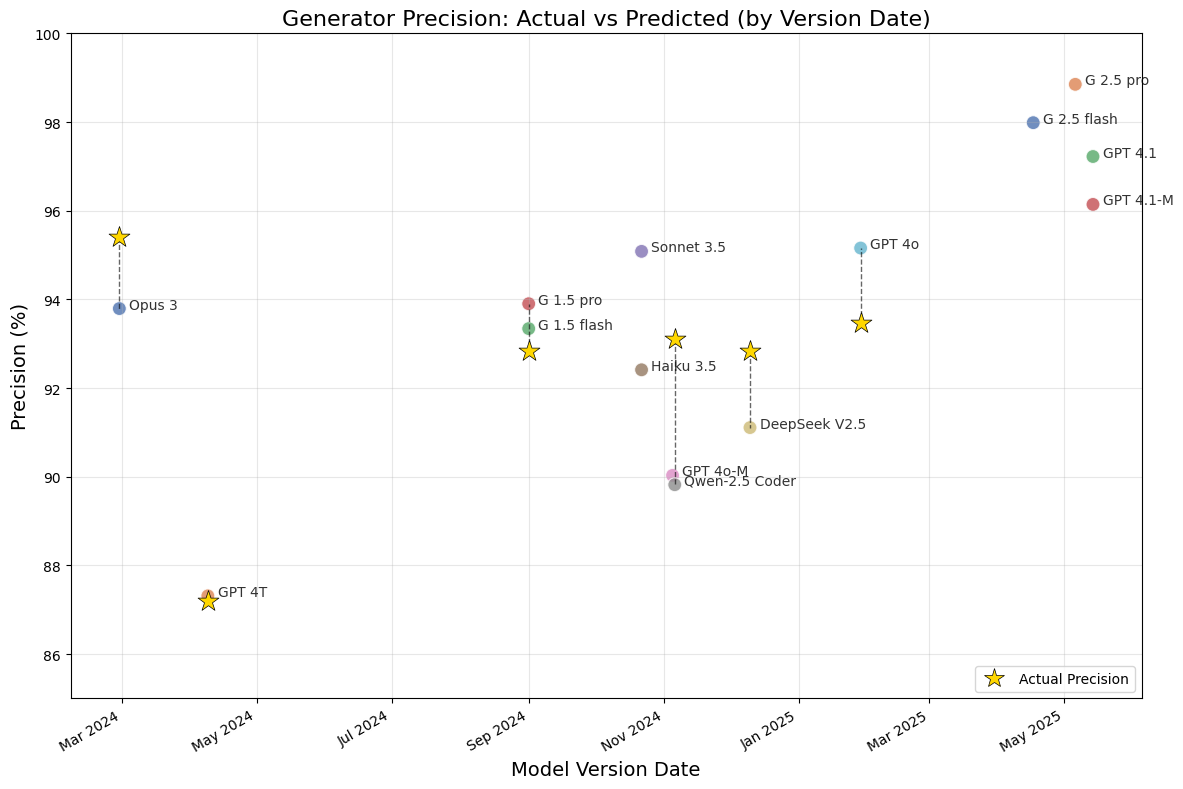

In [38]:
df_plot = plot_precision_over_time(
    df_model_info,
    date_col='version-date',
    x_label='Model Version Date',
    file_path='../output/images/pdfs/precision_by_version_date.pdf',
    title='Generator Precision: Actual vs Predicted (by Version Date)'
)